<a href="https://colab.research.google.com/github/furkandr01/python_data_science/blob/main/Odev6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_way = '/content/drive/MyDrive/Tech Istanbul/enerji_tuketimi.csv'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [ ]:
data = pd.read_csv(data_way)

In [ ]:
X = data[['sicaklik']]
y = data['enerji']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[ 50.27110106  88.11921769  63.21062811 104.61711468 106.23455556
 112.70431909 131.14314513  54.47644735 145.05313672 154.11080565
 136.64244413 119.49757079  60.29923452 116.90966538  38.94901489
 148.93499483  56.41737641  55.1234237  142.14174313 118.52710626]


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, model.predict(X_test))
print('Error score mse: ',mse)
print('Error score r2: ',r2)

Error score mse:  206.04900408277734
Error score r2:  0.6746976494574606


In [ ]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

In [ ]:
from sklearn.neural_network import MLPRegressor

In [ ]:
mlp = MLPRegressor(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train_scaled)

MLPRegressor(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)

In [ ]:
y_pred_scaled = mlp.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
print(y_pred)

[ 62.80833314  44.12090282  52.89621441  70.23040106  74.62327455
  92.19476851 142.2735263   59.58689455 180.05223832 203.60257047
 157.20929617 110.64483717  55.12644112 103.61623959  71.48143703
 190.29344579  58.10007674  59.09128862 172.14506603 108.00911308]


In [ ]:
mse_mlp = mean_squared_error(y_test, y_pred)
r2_mlp = r2_score(y_test, y_pred)
print('MLP MSE: ',mse_mlp)
print('MLP R2: ',r2_mlp)

MLP MSE:  206.04900408277734
MLP R2:  0.9427794068733255


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


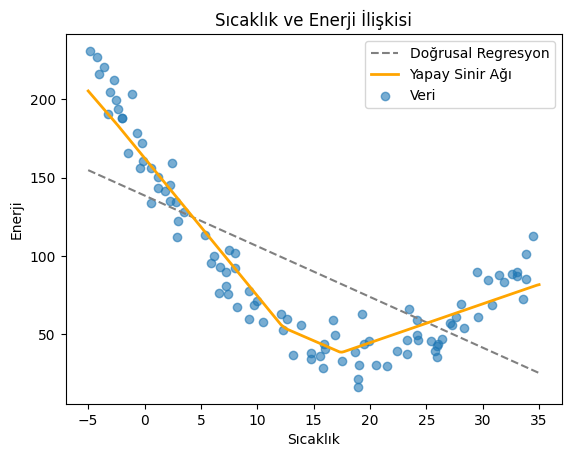

In [ ]:
weights_range = np.linspace(-5, 35, 200)
linear_pred = model.predict(weights_range.reshape(-1, 1))

weights_range_scaled = scaler_X.transform(weights_range.reshape(-1,1))
mlp_pred_scaled = mlp.predict(weights_range_scaled)
mlp_pred = scaler_y.inverse_transform(mlp_pred_scaled.reshape(-1,1)).ravel()

plt.plot(weights_range, linear_pred, color='gray', linestyle='--', label='Doğrusal Regresyon')
plt.plot(weights_range, mlp_pred, color='orange', linewidth=2, label='Yapay Sinir Ağı')
plt.scatter(data['sicaklik'], data['enerji'], label='Veri', alpha=0.6)
plt.xlabel('Sıcaklık')
plt.ylabel('Enerji')
plt.title('Sıcaklık ve Enerji İlişkisi')
plt.legend()
plt.show()